### Autoencoder and VAE on CATS VS DOGS DATASET 

Primer prueba de nuestro AUTOENCODER-VAE en el set de cats vs dogs

In [1]:
import numpy as np
import torch 
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import gzip
import urllib.request as request
import os
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

Cargamos datos y diviidmos en entrenamiento y prueba 

In [2]:
transform_mascotas = transforms.Compose([transforms.Resize((64, 64)), transforms.RandomHorizontalFlip(p=0.5), transforms.ToTensor()])
transform_color = transforms.Compose([transforms.Resize((64, 64)), transforms.ToTensor()])

mascotas_train = datasets.OxfordIIITPet(root='./data_pets', split='trainval', download=True, transform=transform_mascotas)
mascotas_test = datasets.OxfordIIITPet(root='./data_pets_color', split='test', download=True, transform=transform_color)

train_loader = DataLoader(mascotas_train, batch_size=64, shuffle=True)
test_loader = DataLoader(mascotas_test, batch_size=64, shuffle=False)

Visualizamos algunos ejemplos del dataset

In [3]:
def ejemplo_imagenes(images, labels):

    fig, axs = plt.subplots(ncols=len(images), nrows=1, figsize=(10,3))

    for i in range(len(images)):

        imagen_lista = np.transpose(images[i], (1, 2, 0))

        axs[i].imshow(imagen_lista)
        axs[i].set_title(f'Label: {labels[i]}')

        axs[i].set_xticks([])
        axs[i].set_yticks([])
        axs[i].set_xlabel(f'Index: {i}')

    plt.tight_layout()
    plt.show()

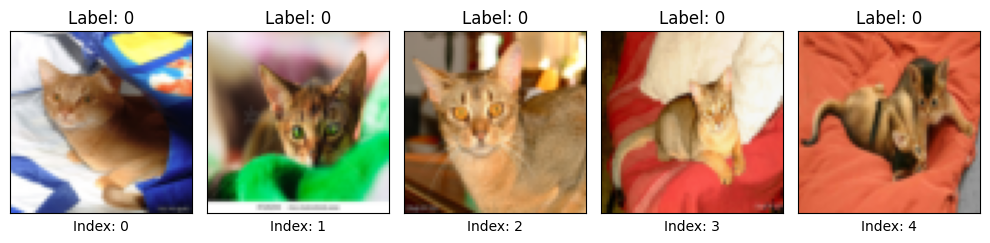

In [4]:
imagenes_ejemplo = np.stack([mascotas_train[i][0].numpy() for i in range(5)])

etiquetas_ejemplo = [mascotas_train[i][1] for i in range(5)]

ejemplo_imagenes(imagenes_ejemplo, etiquetas_ejemplo)

Utilizamos nuestro Auto-Encode, es el mismo que el ejemplo anterior salvo por las dimensiones. Empezamos con 3 canales en vez de uno ya que tenemos imagenes a color (RGB), así mismo probamos una dimension latente de 256. Esto lleva una comprensión de 64 x 64 x 3 a tan solo 256 dimensiones. La selección de la dimensión latente fue algo aleatorio teniendo en cuenta lo siguiente:

- Dimensión latente = 32, Factor de compresión = 12288/32 = 384
- Dimensión latente = 64, Factor de compresión = 12288/32 = 192
- Dimensión latente = 128, Factor de compresión = 12288/32 = 96
- Dimensión latente = 256, Factor de compresión = 12288/32 = 48
- Dimensión latente = 512, Factor de compresión = 12288/32 = 24
- Dimensión latente = 1024, Factor de compresión = 12288/1024 = 12

Así que empezamos con un factor intermedio. Para el set de jets quark/gluon, este parametro de dimensión latente se modificará para ver qué resultados interesantes se pueden obtener.

In [5]:
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        
        self.latent_dim = latent_dim

        #Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),

            nn.ReLU(),
            nn.Flatten()
        )

        #bottleneck
        self.bottleneck = nn.Linear(8192, latent_dim)
        self.decoder_input = nn.Linear(latent_dim, 8192)

        #Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        flat_enconded = self.encoder(x)
        latent_space = self.bottleneck(flat_enconded)

        z_projected = self.decoder_input(latent_space)
        z_reshaped = z_projected.view(-1, 128, 8, 8)

        decoded = self.decoder(z_reshaped)

        return decoded

Definimos una funcion para el entrenamiento de nuestro Auto-Encoder con los parametros necesarios

In [6]:
def train_AutoEncoder(dataset, learning_rate=1e-3, num_epochs=20, batch_size=128):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    model = AutoEncoder(latent_dim=256).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    criterion = nn.MSELoss(reduction='sum')
    
    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(num_epochs):
        total_loss = 0.0
        model.train()
        for batch_idx, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            
            decoded = model(images)
            loss = criterion(decoded, images)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        epoch_loss = total_loss / len(train_loader.dataset)
        print(f'Epoch: {epoch +1}/{num_epochs}: Loss = {epoch_loss:.6f}')

    return model

Entrenamos el modelo durante 30 épocas

In [7]:
model_mascotas = train_AutoEncoder(mascotas_train, num_epochs=30, batch_size=64)

Epoch: 1/30: Loss = 625.873908
Epoch: 2/30: Loss = 336.190752
Epoch: 3/30: Loss = 262.035225
Epoch: 4/30: Loss = 220.504952
Epoch: 5/30: Loss = 189.394372
Epoch: 6/30: Loss = 168.775724
Epoch: 7/30: Loss = 156.528973
Epoch: 8/30: Loss = 146.093586
Epoch: 9/30: Loss = 139.401146
Epoch: 10/30: Loss = 131.238493
Epoch: 11/30: Loss = 123.366245
Epoch: 12/30: Loss = 118.376805
Epoch: 13/30: Loss = 114.127488
Epoch: 14/30: Loss = 107.656773
Epoch: 15/30: Loss = 107.106061
Epoch: 16/30: Loss = 102.488771
Epoch: 17/30: Loss = 97.783593
Epoch: 18/30: Loss = 92.137023
Epoch: 19/30: Loss = 91.785116
Epoch: 20/30: Loss = 90.513275
Epoch: 21/30: Loss = 85.573237
Epoch: 22/30: Loss = 82.612966
Epoch: 23/30: Loss = 81.429652
Epoch: 24/30: Loss = 80.989892
Epoch: 25/30: Loss = 78.300864
Epoch: 26/30: Loss = 76.286612
Epoch: 27/30: Loss = 75.489005
Epoch: 28/30: Loss = 74.815200
Epoch: 29/30: Loss = 73.907494
Epoch: 30/30: Loss = 73.563702


Visualizamos algunos ejemplos

In [8]:
n = 5

device = "cuda" if torch.cuda.is_available() else "cpu"

with torch.no_grad():
    images, labels = next(iter(test_loader))
    images = images[:n].to(device) 

    reconstructed = model_mascotas(images) 

images_np = images.cpu().numpy()
reconstructed_np = reconstructed.cpu().numpy()

Nótese las imagenes reconstruidas, no son cercanas a la imagen original pero conservan las características escenciales de la original.

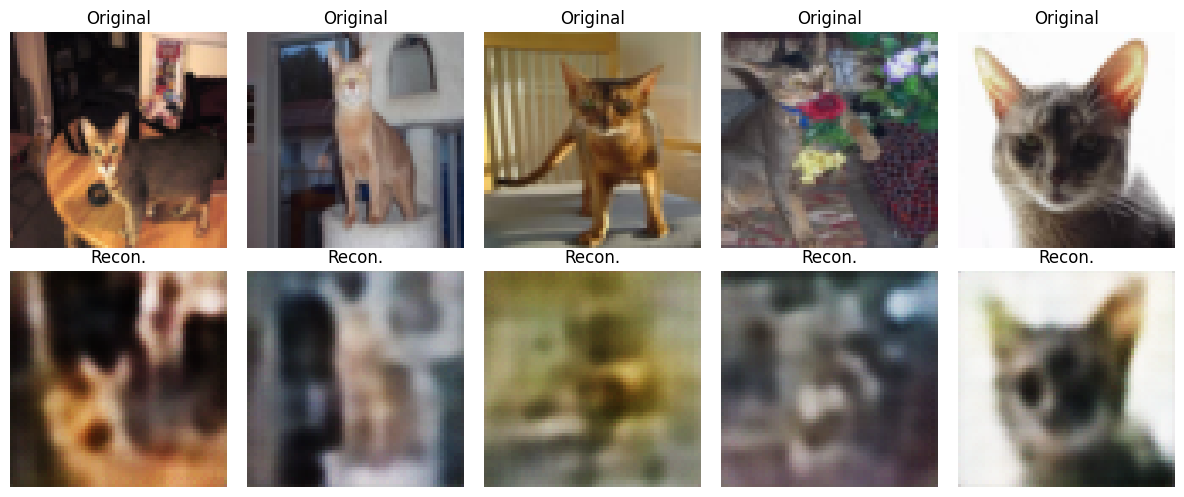

In [9]:
n = 5

fig, axes = plt.subplots(2, n, figsize=(12,5))

for i in range(n):

    axes[0, i].imshow(np.transpose(images_np[i], (1, 2, 0)))
    axes[0, i].set_title("Original")
    axes[0, i].axis('off')

    axes[1, i].imshow(np.transpose(reconstructed_np[i], (1, 2, 0)))
    axes[1, i].set_title("Recon.")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

Para crear el VAE, tomamos como base la estructura del ultimo ejemplo con MNIST, modificando las dimensiones apra ajustarlo al probelma actual.

Se sigue usando el truco de reparametrización que sigue:
$$z = \mu + \epsilon * \sigma$$

In [10]:
class VAEConvolucional(nn.Module):
    def __init__(self, latent_dim=256):
        super().__init__()
        self.latent_dim = latent_dim

        # ENCODER
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1), 
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Flatten() 
        )

        #Bottleneck
        self.mu = nn.Linear(8192, latent_dim)
        self.log_var = nn.Linear(8192, latent_dim)

        # DECODER
        self.decoder_input = nn.Linear(latent_dim, 8192)
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid() 
        )

    def reparametrizacion(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        hidden = self.encoder(x)
        mu = self.mu(hidden)
        log_var = self.log_var(hidden)
        
        z = self.reparametrizacion(mu, log_var)
        
        z_projected = self.decoder_input(z)
        z_reshaped = z_projected.view(-1, 128, 8, 8) 
        
        decoded = self.decoder(z_reshaped)
        return decoded, mu, log_var

Nuevamente hacemos el calculo de la función de pérdida, para esta caso tambien usamos la variante $\beta$-VAE con un factor $\beta$=0.1

In [11]:
def loss_function_beta(recon_x, x, mu, log_var, beta=0.1):
    BCE = F.binary_cross_entropy(recon_x.view(recon_x.size(0), -1), x.view(x.size(0), -1), reduction='sum')
    KLD = -0.5 *torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
    total_loss = BCE + (beta*KLD)

    return total_loss, BCE, KLD

Definimos una función de entrenamiento, usando los siguientes parametros:

- Usamos learning rate de 0.001, al principio
- Optimizador Adam
- Agregamos un Schedulre para el learning rate para refinar el entrenamiento de la red neuronal.
- Entrenamos duarante 100 épocas



In [12]:
def train_VAE(dataset, learning_rate=1e-3, num_epochs=100, batch_size=64, beta=0.1):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    model = VAEConvolucional(latent_dim=256).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)
    
    train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(num_epochs):
        total_loss = 0.0
        total_bce = 0.0
        total_kld = 0.0
        model.train()
        for batch_idx, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            
            decoded, mu, log_var = model(images)
            loss, bce, kld = loss_function_beta(decoded, images, mu, log_var, beta=beta)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_bce += bce.item()
            total_kld += kld.item()

        scheduler.step()

        current_lr = scheduler.get_last_lr()[0]

        epoch_loss = total_loss / len(train_loader.dataset)
        epoch_bce = total_bce / len(train_loader.dataset)
        epoch_kld = total_kld / len(train_loader.dataset)
        
        print(f'Epoch: {epoch + 1}/{num_epochs} | LR: {current_lr:.6f} | Loss Total: {epoch_loss:.6f} | BCE: {epoch_bce:.6f} | KLD: {epoch_kld:.6f}')

    return model

In [13]:
model_mascotas2 = train_VAE(mascotas_train, num_epochs=100, batch_size=64, beta = 0.1)

Epoch: 1/100 | LR: 0.001000 | Loss Total: 7712.545041 | BCE: 7664.211252 | KLD: 483.338009
Epoch: 2/100 | LR: 0.001000 | Loss Total: 7223.299728 | BCE: 7180.555817 | KLD: 427.439405
Epoch: 3/100 | LR: 0.001000 | Loss Total: 7126.821196 | BCE: 7084.007604 | KLD: 428.135750
Epoch: 4/100 | LR: 0.001000 | Loss Total: 7045.539415 | BCE: 7001.454280 | KLD: 440.851324
Epoch: 5/100 | LR: 0.001000 | Loss Total: 7000.204768 | BCE: 6955.141024 | KLD: 450.637469
Epoch: 6/100 | LR: 0.001000 | Loss Total: 6966.687916 | BCE: 6922.064054 | KLD: 446.238920
Epoch: 7/100 | LR: 0.001000 | Loss Total: 6950.102246 | BCE: 6904.585691 | KLD: 455.165834
Epoch: 8/100 | LR: 0.001000 | Loss Total: 6933.058853 | BCE: 6887.416084 | KLD: 456.428226
Epoch: 9/100 | LR: 0.001000 | Loss Total: 6919.211375 | BCE: 6873.666470 | KLD: 455.448786
Epoch: 10/100 | LR: 0.001000 | Loss Total: 6909.681157 | BCE: 6863.867714 | KLD: 458.134353
Epoch: 11/100 | LR: 0.001000 | Loss Total: 6899.376885 | BCE: 6853.434672 | KLD: 459.4220

Gráficamos algunos ejemplos

Nuevamente nótese las imagenes reconstruidas, no son cercanas a la imagen original pero conservan las características de la original, lo que nos sugiere que la red sí esta aprendiendo, aunque le falta mucho para conseguir la estructura deseada. 

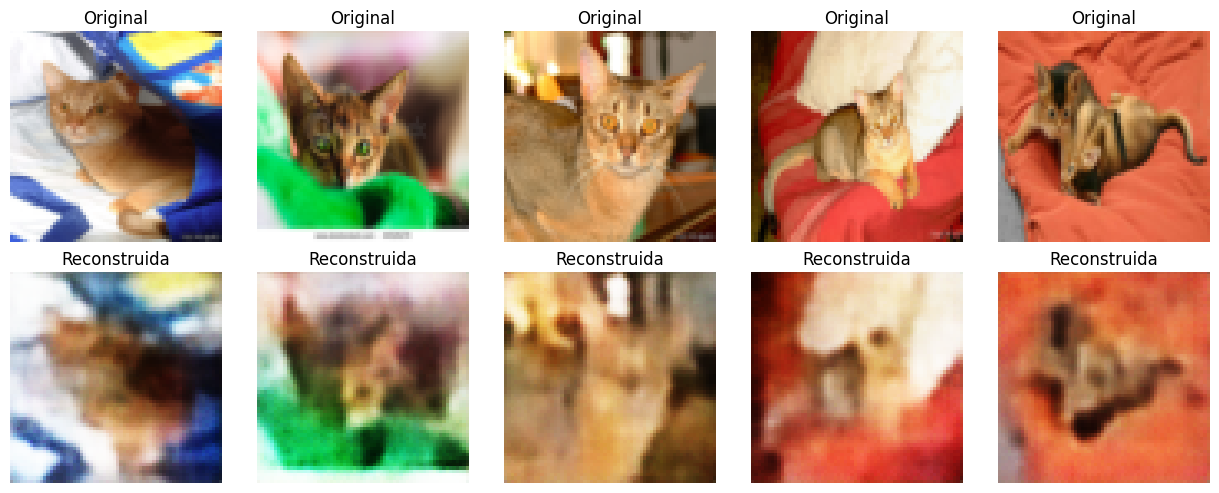

In [14]:
def ver_reconstrucciones_color(model, dataset, num_images=5):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.eval()
    
    images = torch.stack([dataset[i][0] for i in range(num_images)]).to(device)
    
    with torch.no_grad():
        decoded, _, _ = model(images)
        
    images = images.cpu()
    decoded = decoded.cpu()
    
    fig, axes = plt.subplots(2, num_images, figsize=(num_images * 2.5, 5))
    
    for i in range(num_images):
        axes[0, i].imshow(images[i].permute(1, 2, 0))
        axes[0, i].axis('off')
        axes[0, i].set_title('Original')
            
        axes[1, i].imshow(decoded[i].permute(1, 2, 0))
        axes[1, i].axis('off')
        axes[1, i].set_title('Reconstruida')
            
    plt.tight_layout()
    plt.show()

ver_reconstrucciones_color(model_mascotas2, mascotas_train)